In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [66]:
data=pd.read_csv('../datasets/PJME_preprocessd.csv',parse_dates=['Datetime'],index_col='Datetime')

In [67]:
scaler = MinMaxScaler()
scaler.fit(data[['PJME_MW']])

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value
"data_max_ data_max_: ndarray of shape (n_features,)Per feature maximum seen in the data.. versionadded:: 0.17 *data_max_*","ndarray[float64](1,)",[47761.]
"data_min_ data_min_: ndarray of shape (n_features,)Per feature minimum seen in the data.. versionadded:: 0.17 *data_min_*","ndarray[float64](1,)",[15457.]
"data_range_ data_range_: ndarray of shape (n_features,)Per feature range ``(data_max_ - data_min_)`` seen in the data.. versionadded:: 0.17 *data_range_*","ndarray[float64](1,)",[32304.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['PJME_MW']
"min_ min_: ndarray of shape (n_features,)Per feature adjustment for minimum. Equivalent to``min - X.min(axis=0) * self.scale_``","ndarray[float64](1,)",[-0.48]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
"n_samples_seen_ n_samples_seen_: intThe number of samples processed by the estimator.It will be reset on new calls to fit, but increments across``partial_fit`` calls.",int,145224


In [68]:
series=data['PJME_MW_Scaled']
series.head()

Datetime
2002-01-08 01:00:00    0.433011
2002-01-08 02:00:00    0.409021
2002-01-08 03:00:00    0.399889
2002-01-08 04:00:00    0.405058
2002-01-08 05:00:00    0.427316
Name: PJME_MW_Scaled, dtype: float64

In [69]:
train_size=int(len(series)*0.70)
val_size=int(len(series)*0.10)
train = series.iloc[:train_size]
validation = series.iloc[train_size:train_size + val_size]
test = series.iloc[train_size + val_size:]
print('Train:', len(train))
print('Validation:', len(validation))
print('Test:', len(test))

Train: 101656
Validation: 14522
Test: 29046


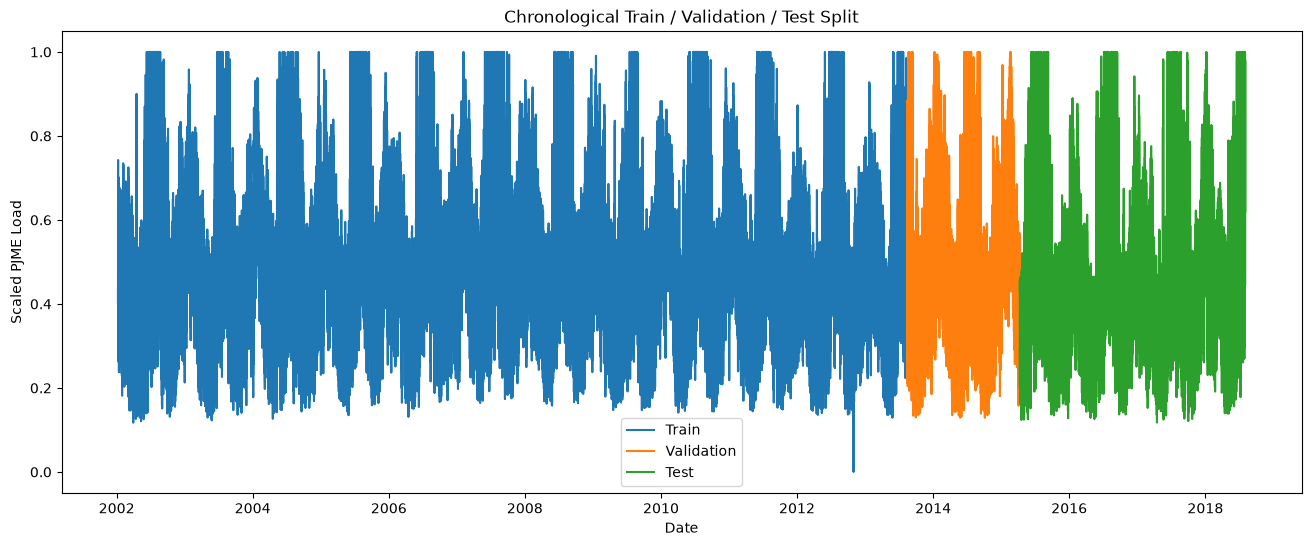

In [70]:
plt.figure(figsize=(16,6))
plt.plot(train.index, train, label='Train')
plt.plot(validation.index, validation, label='Validation')
plt.plot(test.index, test, label='Test')
plt.title('Chronological Train / Validation / Test Split')
plt.xlabel('Date')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

In [71]:
def create_sequences(series,sequence_length):
    X=[]
    y=[]
    values=series.values
    for i in range(len(values)-sequence_length):
        X.append(values[i:i + sequence_length])
        y.append(values[i + sequence_length])
    return np.array(X), np.array(y)
        

In [72]:
sequence_length = 24

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101632, 24)
(101632,)
(14498, 24)
(14498,)
(29022, 24)
(29022,)


In [73]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101632, 24, 1)
(14498, 24, 1)
(29022, 24, 1)


# Basic RNN Model

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(24)])
rnn_model.summary()    

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
rnn_model.compile(optimizer='adam',loss='mse')

In [25]:
basic_rnn_history=rnn_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 0.0013 - val_loss: 3.2116e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 3.0029e-04 - val_loss: 2.5850e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - loss: 2.5270e-04 - val_loss: 2.0169e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.4291e-04 - val_loss: 2.0865e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 2.3080e-04 - val_loss: 1.8687e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.1694e-04 - val_loss: 1.8239e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - loss: 2.0774e-04 - val_loss: 1.7711e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1.9874e-04 - val_loss: 1.6537e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1.9388e-04 - val_loss: 1.5839e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 1.8926e-04 - val_loss: 1.9699e-04


In [26]:
basic_rnn_history.history.keys()

dict_keys(['loss', 'val_loss'])

In [28]:
rnn_model.save('../models/rnn_24.keras')

## make prediction

In [21]:
rnn_predictions=rnn_model.predict(X_test)
rnn_predictions=rnn_predictions.flatten()
rnn_predictions[:5]

907/907 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


array([0.29931274, 0.32012174, 0.34465975, 0.37170458, 0.30075637],
      dtype=float32)

## Evaluate the RNN model

In [23]:
rnn_mae = mean_absolute_error(y_test, rnn_predictions)
rnn_rmse = np.sqrt(mean_squared_error(y_test, rnn_predictions))
print("RNN MAE :", round(rnn_mae, 3))
print("RNN RMSE:", round(rnn_rmse, 3))

RNN MAE : 0.01
RNN RMSE: 0.013


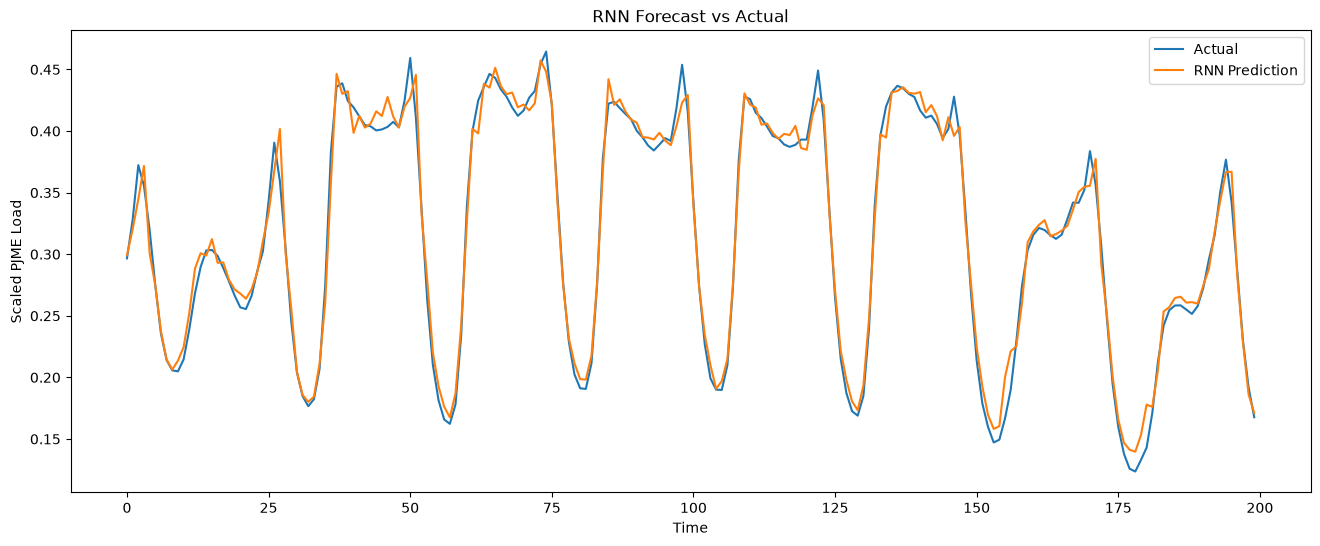

In [24]:
plt.figure(figsize=(16,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(rnn_predictions[:200], label='RNN Prediction')
plt.title('RNN Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

# LSTM

In [29]:
from tensorflow.keras.layers import LSTM,Dense
lstm_model = Sequential([
    LSTM(32, input_shape=(sequence_length,1)),
    Dense(1)
])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
lstm_model.compile(optimizer='adam',loss='mse')

In [31]:
lstm_history=lstm_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 0.0027 - val_loss: 5.1082e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 4.4708e-04 - val_loss: 3.2809e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 3.6713e-04 - val_loss: 2.8866e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 3.1661e-04 - val_loss: 2.4767e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 2.6814e-04 - val_loss: 2.1362e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 2.3046e-04 - val_loss: 1.9566e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 2.1716e-04 - val_loss: 1.6109e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - loss: 2.0088e-04 - val_loss: 1.8156e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 1.8953e-04 - val_loss: 1.5700e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 1.8052e-04 - val_loss: 1.6135e-04


In [32]:
lstm_model.save('../models/lstm_24.keras')

# make prediction

In [28]:
lstm_predictions=lstm_model.predict(X_test)
lstm_predictions=lstm_predictions.flatten()
lstm_predictions[:5]

907/907 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step


array([0.31521913, 0.33400378, 0.3658714 , 0.37741473, 0.3239544 ],
      dtype=float32)

In [29]:
lstm_mae = mean_absolute_error(y_test, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test, lstm_predictions))
print("LSTM MAE :", round(lstm_mae, 3))
print("LSTM RMSE:", round(lstm_rmse, 3))

LSTM MAE : 0.009
LSTM RMSE: 0.013


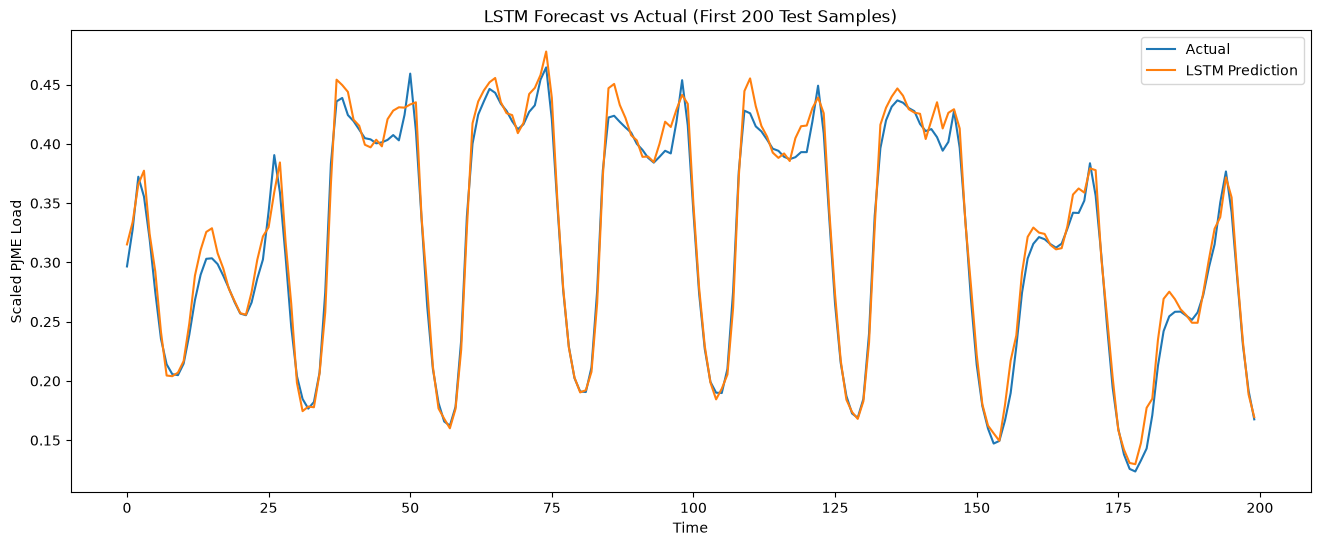

In [30]:
plt.figure(figsize=(16,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(lstm_predictions[:200], label='LSTM Prediction')
plt.title('LSTM Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

# GRU

In [33]:
from tensorflow.keras.layers import GRU,Dense
gru_model = Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(1)
])
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
gru_model.compile(optimizer='adam',loss='mse')

In [35]:
gru_history=gru_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - loss: 0.0020 - val_loss: 3.7238e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 4.2561e-04 - val_loss: 4.0350e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 3.9070e-04 - val_loss: 3.1253e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 3.5573e-04 - val_loss: 2.9240e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 3.0789e-04 - val_loss: 2.4304e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - loss: 2.5171e-04 - val_loss: 1.9678e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 2.3133e-04 - val_loss: 1.9564e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 2.1524e-04 - val_loss: 1.7157e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 2.0216e-04 - val_loss: 2.0329e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 18s 6ms/step - loss: 1.9024e-04 - val_loss: 1.4630e-04


In [36]:
gru_model.save('../models/gru_24.keras')

# MAke prediction

In [35]:
gru_predictions = gru_model.predict(X_test)
gru_predictions = gru_predictions.flatten()
gru_predictions[:5]

907/907 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


array([0.31946522, 0.3326116 , 0.36062747, 0.38934487, 0.3237639 ],
      dtype=float32)

In [36]:
gru_mae = mean_absolute_error(y_test, gru_predictions)
gru_rmse = np.sqrt(mean_squared_error(y_test, gru_predictions))
print("GRU MAE :", round(gru_mae, 3))
print("GRU RMSE:", round(gru_rmse, 3))

GRU MAE : 0.011
GRU RMSE: 0.014


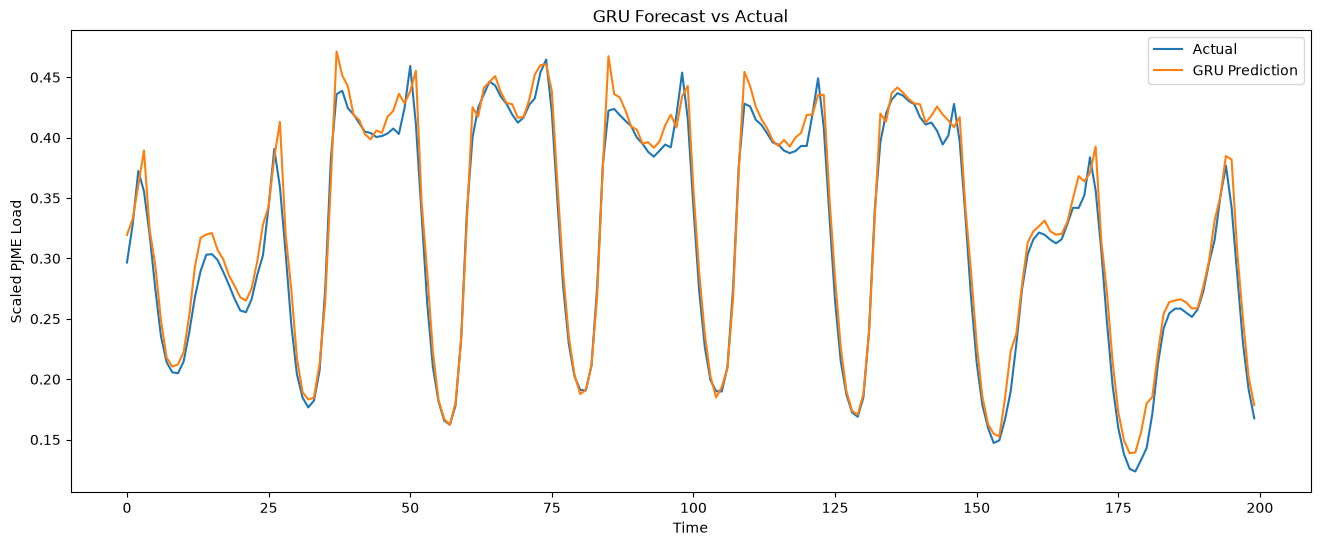

In [37]:
plt.figure(figsize=(16,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(gru_predictions[:200], label='GRU Prediction')
plt.title('GRU Forecast vs Actual')
plt.xlabel('Time')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

# Bidirectional LSTM

In [37]:
from tensorflow.keras.layers import LSTM,Dense,Bidirectional
bilstm_model = Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length,1)),
    Dense(1)
])
bilstm_model.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
bilstm_model.compile(optimizer='adam',loss='mse')

In [39]:
bilstm_history=bilstm_model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 24s 7ms/step - loss: 0.0034 - val_loss: 5.5751e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 4.1852e-04 - val_loss: 2.7141e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 29s 9ms/step - loss: 2.9849e-04 - val_loss: 2.8022e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 2.5032e-04 - val_loss: 2.3893e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 2.3750e-04 - val_loss: 1.8239e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 2.1620e-04 - val_loss: 1.5720e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 1.9370e-04 - val_loss: 1.5369e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.8111e-04 - val_loss: 1.6173e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.7158e-04 - val_loss: 1.3672e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 1.6293e-04 - val_loss: 1.3418e-04


In [40]:
bilstm_model.save('../models/bilstm_24.keras')

# make prediction

In [41]:
bilstm_predictions=bilstm_model.predict(X_test)
bilstm_predictions=bilstm_predictions.flatten()
bilstm_predictions[:5]

907/907 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


array([0.30874595, 0.34090778, 0.36089447, 0.36850545, 0.30716124],
      dtype=float32)

In [42]:
bilstm_mae = mean_absolute_error(y_test, bilstm_predictions)
bilstm_rmse = np.sqrt(mean_squared_error(y_test, bilstm_predictions))
print("Bi-LSTM MAE :", round(bilstm_mae, 3))
print("Bi-LSTM RMSE:", round(bilstm_rmse, 3))

Bi-LSTM MAE : 0.008
Bi-LSTM RMSE: 0.011


In [43]:
bilstm_mae = mean_absolute_error(y_test,bilstm_predictions)
bilstm_rmse = np.sqrt(mean_squared_error(y_test,bilstm_predictions))
print("Bi-LSTM MAE :", round(bilstm_mae, 3))
print("Bi-LSTM RMSE:", round(bilstm_rmse, 3))

Bi-LSTM MAE : 0.008
Bi-LSTM RMSE: 0.011


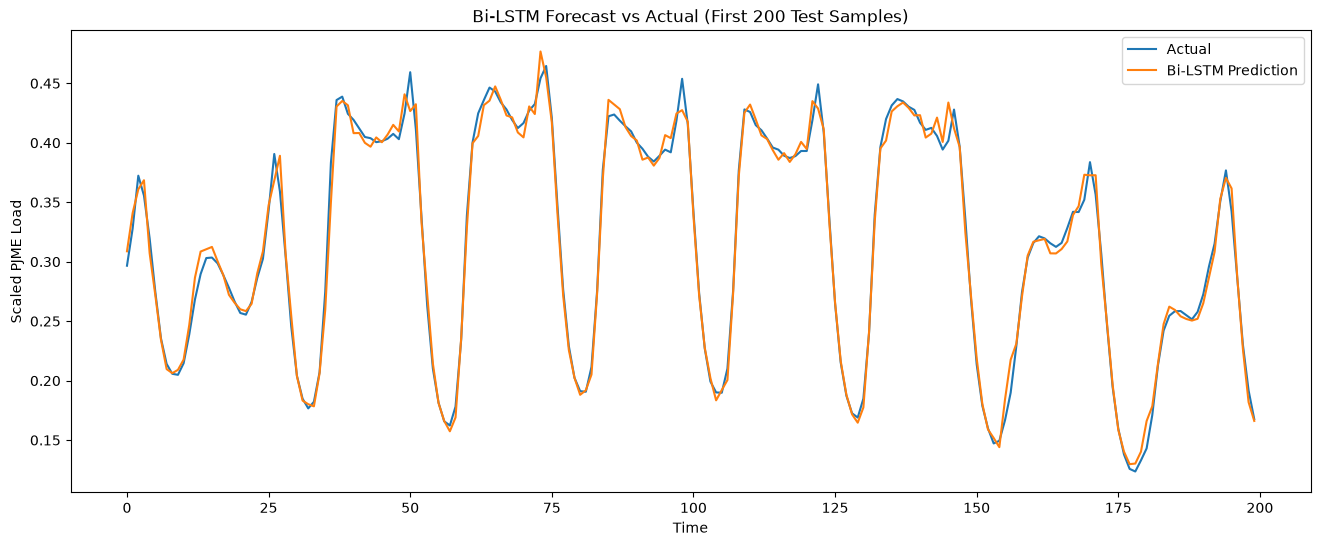

In [44]:
plt.figure(figsize=(16,6))
plt.plot(y_test[:200], label='Actual')
plt.plot(bilstm_predictions[:200], label='Bi-LSTM Prediction')
plt.title('Bi-LSTM Forecast vs Actual (First 200 Test Samples)')
plt.xlabel('Time')
plt.ylabel('Scaled PJME Load')
plt.legend()
plt.show()

In [46]:
comparison = pd.DataFrame({
    'Model': ['Basic RNN','LSTM','GRU','Bidirectional LSTM'],
    'MAE': [rnn_mae,lstm_mae,gru_mae,bilstm_mae],
    'RMSE': [rnn_rmse,lstm_rmse,gru_rmse,bilstm_rmse]
})

comparison.sort_values('RMSE')

,Model,MAE,RMSE
3,Bidirectional LSTM,0.008115,0.011142
1,LSTM,0.009218,0.012842
0,Basic RNN,0.009806,0.012982
2,GRU,0.010594,0.013727


In [47]:
comparison.to_csv('../datasets/deep_learning_model_comparison.csv', index=False)


# sequntial lenght=48

In [9]:
sequence_length =48

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101608, 48)
(101608,)
(14474, 48)
(14474,)
(28998, 48)
(28998,)


In [10]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101608, 48, 1)
(14474, 48, 1)
(28998, 48, 1)


In [26]:
print(X_train[0].shape)
print(X_train[0][:5])


(48, 1)
[[0.43301139]
 [0.40902055]
 [0.39988856]
 [0.4050582 ]
 [0.4273155 ]]


# Basic RNN

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model_48=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(1)])
rnn_model_48.compile(optimizer='adam',loss='mse')
rnn_model_48.summary()    

I0000 00:00:1786338963.232016   38893 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786338963.321749   38893 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786338965.333781   38893 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1786338965.622926   38893 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` ob

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
basic_rnn48_history=rnn_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 55s 17ms/step - loss: 0.0013 - val_loss: 3.3019e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 69s 22ms/step - loss: 2.1062e-04 - val_loss: 1.6776e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - loss: 1.6285e-04 - val_loss: 1.1706e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 66s 21ms/step - loss: 1.4966e-04 - val_loss: 9.9847e-05
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 70s 22ms/step - loss: 1.4242e-04 - val_loss: 1.1205e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - loss: 1.3895e-04 - val_loss: 9.9894e-05
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - loss: 1.3805e-04 - val_loss: 1.0933e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 1.3423e-04 - val_loss: 1.0276e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 71s 22ms/step - loss: 1.3200e-04 - val_loss: 1.1343e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 1.3100e-04 - val_loss: 1.0850e-04


In [28]:
rnn48_predictions = rnn_model_48.predict(X_test)
rnn48_predictions = rnn48_predictions.flatten()
rnn48_mae = mean_absolute_error(y_test, rnn48_predictions)
rnn48_rmse = np.sqrt(mean_squared_error(y_test, rnn48_predictions))
print("RNN (48) MAE :", round(rnn48_mae,6))
print("RNN (48) RMSE:", round(rnn48_rmse,6))

907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
RNN (48) MAE : 0.007746
RNN (48) RMSE: 0.010193


In [14]:
rnn_model_48.save('../models/rnn_48.keras')

# LSTM

In [15]:
from tensorflow.keras.layers import LSTM,Dense
lstm_model_48 = Sequential([
    LSTM(32, input_shape=(sequence_length,1)),
    Dense(1)
])
lstm_model_48.compile(optimizer='adam',loss='mse')
lstm_model_48.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
lstm_48_history=lstm_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 130s 40ms/step - loss: 0.0031 - val_loss: 4.6110e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 127s 40ms/step - loss: 4.3393e-04 - val_loss: 2.8691e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 119s 37ms/step - loss: 3.3161e-04 - val_loss: 3.2484e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 92s 29ms/step - loss: 3.0675e-04 - val_loss: 2.8271e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 129s 41ms/step - loss: 2.7559e-04 - val_loss: 2.2572e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 124s 39ms/step - loss: 2.4017e-04 - val_loss: 2.1437e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 60s 19ms/step - loss: 2.1998e-04 - val_loss: 2.0445e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 2.0027e-04 - val_loss: 1.8430e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 35s 11ms/step - loss: 1.8750e-04 - val_loss: 1.4255e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 37s 12ms/step - loss: 1.7366e-04 - val_loss: 1.4502e-04


In [29]:
lstm48_predictions = lstm_model_48.predict(X_test)
lstm48_predictions = lstm48_predictions.flatten()
lstm48_mae = mean_absolute_error(y_test, lstm48_predictions)
lstm48_rmse = np.sqrt(mean_squared_error(y_test, lstm48_predictions))
print("LSTM (48) MAE :", round(lstm48_mae,6))
print("LSTM (48) RMSE:", round(lstm48_rmse,6))

907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
LSTM (48) MAE : 0.008601
LSTM (48) RMSE: 0.011561


In [18]:
lstm_model_48.save('../models/lstm_48.keras')

# GRU

In [19]:
from tensorflow.keras.layers import GRU,Dense
gru_model_48= Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(1)
])
gru_model_48.compile(optimizer='adam',loss='mse')
gru_model_48.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
gru_48_history=gru_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 46s 14ms/step - loss: 0.0037 - val_loss: 5.9070e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 44s 14ms/step - loss: 5.0520e-04 - val_loss: 3.7426e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 50s 16ms/step - loss: 4.3965e-04 - val_loss: 3.4141e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 3.2303e-04 - val_loss: 2.4548e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 2.8083e-04 - val_loss: 2.1833e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 2.5357e-04 - val_loss: 2.3919e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 2.2196e-04 - val_loss: 1.7137e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 1.8652e-04 - val_loss: 1.4353e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 1.7004e-04 - val_loss: 1.3325e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 14ms/step - loss: 1.5770e-04 - val_loss: 1.2992e-04


In [30]:
gru48_predictions = gru_model_48.predict(X_test)
gru48_predictions = lstm48_predictions.flatten()
gru48_mae = mean_absolute_error(y_test, gru48_predictions)
gru48_rmse = np.sqrt(mean_squared_error(y_test, gru48_predictions))
print("GRU (48) MAE :", round(gru48_mae,6))
print("GRU (48) RMSE:", round(gru48_rmse,6))

907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
GRU (48) MAE : 0.008601
GRU (48) RMSE: 0.011561


In [22]:
gru_model_48.save('../models/gru_48.keras')

# Bidirectional LSTM

In [23]:
from tensorflow.keras.layers import LSTM,Dense,Bidirectional
bilstm_model_48= Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length,1)),
    Dense(1)
])
bilstm_model_48.compile(optimizer='adam',loss='mse')
bilstm_model_48.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
bilstm_48_history=bilstm_model_48.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 43s 13ms/step - loss: 0.0029 - val_loss: 5.4615e-04
Epoch 2/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 49s 15ms/step - loss: 3.8196e-04 - val_loss: 3.2876e-04
Epoch 3/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 2.8568e-04 - val_loss: 2.4082e-04
Epoch 4/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 2.4158e-04 - val_loss: 1.7662e-04
Epoch 5/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 2.0370e-04 - val_loss: 1.9462e-04
Epoch 6/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 1.8270e-04 - val_loss: 2.2628e-04
Epoch 7/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 51s 16ms/step - loss: 1.6945e-04 - val_loss: 1.5176e-04
Epoch 8/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 48s 15ms/step - loss: 1.5893e-04 - val_loss: 1.2656e-04
Epoch 9/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 1.5023e-04 - val_loss: 1.3133e-04
Epoch 10/10
3176/3176 ━━━━━━━━━━━━━━━━━━━━ 47s 15ms/step - loss: 1.4108e-04 - val_loss: 1.2641e-04


In [27]:
bilstm48_predictions = bilstm_model_48.predict(X_test)
bilstm48_predictions = bilstm48_predictions.flatten()
bilstm48_mae = mean_absolute_error(y_test, bilstm48_predictions)
bilstm48_rmse = np.sqrt(mean_squared_error(y_test, bilstm48_predictions))
print("Bidirectional LSTm (48) MAE :", round(bilstm48_mae,6))
print("Bidirectional LSTm (48) RMSE:", round(bilstm48_rmse,6))

907/907 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Bidirectional LSTm (48) MAE : 0.008135
Bidirectional LSTm (48) RMSE: 0.011375


In [46]:
bilstm_model_48.save('../models/bilstm_48.keras')

# Sequential length =168(week)

In [11]:
sequence_length =168

X_train,y_train = create_sequences(train,sequence_length)
X_val,y_val = create_sequences(validation,sequence_length)
X_test,y_test = create_sequences(test,sequence_length)
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)
print(X_test.shape)
print(y_test.shape)

(101488, 168)
(101488,)
(14354, 168)
(14354,)
(28878, 168)
(28878,)


In [33]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(101488, 168, 1)
(14354, 168, 1)
(28878, 168, 1)


# Basic RNN

In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense
rnn_model_168=Sequential([
    SimpleRNN(32,input_shape=(sequence_length,1)),
    Dense(1)])
rnn_model_168.compile(optimizer='adam',loss='mse')
rnn_model_168.summary()    

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,121 (4.38 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
basic_rnn168_history=rnn_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 52s 16ms/step - loss: 8.3658e-04 - val_loss: 1.9451e-04
Epoch 2/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 58s 18ms/step - loss: 1.6818e-04 - val_loss: 1.1140e-04
Epoch 3/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 63s 20ms/step - loss: 1.4656e-04 - val_loss: 1.0911e-04
Epoch 4/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 61s 19ms/step - loss: 1.4563e-04 - val_loss: 1.2067e-04
Epoch 5/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 59s 19ms/step - loss: 1.3844e-04 - val_loss: 1.0060e-04
Epoch 6/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 102s 32ms/step - loss: 1.3486e-04 - val_loss: 1.1286e-04
Epoch 7/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 171s 54ms/step - loss: 1.3108e-04 - val_loss: 9.3850e-05
Epoch 8/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 165s 52ms/step - loss: 1.2977e-04 - val_loss: 1.0324e-04
Epoch 9/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 143s 45ms/step - loss: 1.2632e-04 - val_loss: 9.5848e-05
Epoch 10/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 187s 59ms/step - loss: 1.2427e-04 - val_loss: 9.0967e-05


In [36]:
rnn168_predictions = rnn_model_168.predict(X_test)
rnn168_predictions = rnn168_predictions.flatten()
rnn168_mae = mean_absolute_error(y_test, rnn168_predictions)
rnn168_rmse = np.sqrt(mean_squared_error(y_test, rnn168_predictions))
print("RNN (168) MAE :", round(rnn168_mae,6))
print("RNN (168) RMSE:", round(rnn168_mae,6))

903/903 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step
RNN (168) MAE : 0.006743
RNN (168) RMSE: 0.006743


In [37]:
rnn_model_168.save('../models/basic_rnn168.keras')

# LSTM

In [38]:
from tensorflow.keras.layers import LSTM,Dense
lstm_model_168 = Sequential([
    LSTM(32, input_shape=(sequence_length,1)),
    Dense(1)
])
lstm_model_168.compile(optimizer='adam',loss='mse')
lstm_model_168.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385 (17.13 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
lstm_168_history=lstm_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 326s 102ms/step - loss: 0.0030 - val_loss: 5.9455e-04
Epoch 2/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 355s 112ms/step - loss: 4.6406e-04 - val_loss: 3.7272e-04
Epoch 3/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 332s 105ms/step - loss: 3.4949e-04 - val_loss: 2.8480e-04
Epoch 4/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 353s 111ms/step - loss: 3.0302e-04 - val_loss: 2.2847e-04
Epoch 5/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 335s 106ms/step - loss: 2.4134e-04 - val_loss: 1.7415e-04
Epoch 6/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 359s 113ms/step - loss: 2.0317e-04 - val_loss: 1.5881e-04
Epoch 7/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 354s 112ms/step - loss: 1.8515e-04 - val_loss: 1.5293e-04
Epoch 8/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 177s 56ms/step - loss: 1.6681e-04 - val_loss: 1.4738e-04
Epoch 9/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 120s 38ms/step - loss: 1.5384e-04 - val_loss: 1.3047e-04
Epoch 10/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 111s 35ms/step - loss: 1.4242e-04 - val_loss: 1.3463e-04


In [40]:
lstm168_predictions = lstm_model_168.predict(X_test)
lstm168_predictions = lstm168_predictions.flatten()
lstm168_mae = mean_absolute_error(y_test, lstm168_predictions)
lstm168_rmse = np.sqrt(mean_squared_error(y_test, lstm168_predictions))
print("LSTM (168) MAE :", round(lstm168_mae,6))
print("LSTM (168) RMSE:", round(lstm168_rmse,6))

903/903 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
LSTM (168) MAE : 0.00906
LSTM (168) RMSE: 0.012053


In [41]:
lstm_model_168.save('../models/lstm_168.keras')

# GRU

In [42]:
from tensorflow.keras.layers import GRU,Dense
gru_model_168= Sequential([
    GRU(32,input_shape=(sequence_length,1)),
    Dense(1)
])
gru_model_168.compile(optimizer='adam',loss='mse')
gru_model_168.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 32)             │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
gru_168_history=gru_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 150s 47ms/step - loss: 0.0019 - val_loss: 5.0940e-04
Epoch 2/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 147s 46ms/step - loss: 4.7166e-04 - val_loss: 6.0456e-04
Epoch 3/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 155s 49ms/step - loss: 4.4912e-04 - val_loss: 3.8838e-04
Epoch 4/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 150s 47ms/step - loss: 3.6701e-04 - val_loss: 2.3204e-04
Epoch 5/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 150s 47ms/step - loss: 2.5777e-04 - val_loss: 1.8714e-04
Epoch 6/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 150s 47ms/step - loss: 2.0842e-04 - val_loss: 1.7331e-04
Epoch 7/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 157s 50ms/step - loss: 1.9073e-04 - val_loss: 1.6728e-04
Epoch 8/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 165s 52ms/step - loss: 1.7818e-04 - val_loss: 1.3621e-04
Epoch 9/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 159s 50ms/step - loss: 1.6685e-04 - val_loss: 1.4703e-04
Epoch 10/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 154s 49ms/step - loss: 1.5925e-04 - val_loss: 1.2852e-04


In [45]:
gru168_predictions = gru_model_168.predict(X_test)
gru168_predictions = gru168_predictions.flatten()
gru168_mae = mean_absolute_error(y_test, gru168_predictions)
gru168_rmse = np.sqrt(mean_squared_error(y_test, gru168_predictions))
print("GRU (168) MAE :", round(gru168_mae,6))
print("GRU (168) RMSE:", round(gru168_rmse,6))

903/903 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
GRU (168) MAE : 0.008271
GRU (168) RMSE: 0.011419


In [47]:
gru_model_168.save('../models/gru_168.keras')

In [48]:
from tensorflow.keras.layers import LSTM,Dense,Bidirectional
bilstm_model_168= Sequential([
    Bidirectional(LSTM(32), input_shape=(sequence_length,1)),
    Dense(1)
])
bilstm_model_168.compile(optimizer='adam',loss='mse')
bilstm_model_168.summary()

/home/aximsoft/.local/share/virtualenvs/electricity-forecasting-YpekzRm1/lib/python3.12/site-packages/keras/src/layers/rnn/bidirectional.py:110: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 64)             │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,769 (34.25 KB)

 Trainable params: 8,769 (34.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
bilstm_168_history=bilstm_model_168.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=10,batch_size=32)

Epoch 1/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 164s 51ms/step - loss: 0.0026 - val_loss: 9.9188e-04
Epoch 2/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 156s 49ms/step - loss: 3.8502e-04 - val_loss: 3.4735e-04
Epoch 3/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 153s 48ms/step - loss: 2.6115e-04 - val_loss: 1.7608e-04
Epoch 4/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 155s 49ms/step - loss: 2.1183e-04 - val_loss: 1.6267e-04
Epoch 5/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 160s 50ms/step - loss: 1.9254e-04 - val_loss: 1.7102e-04
Epoch 6/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 154s 48ms/step - loss: 1.7812e-04 - val_loss: 1.4229e-04
Epoch 7/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 154s 49ms/step - loss: 1.6488e-04 - val_loss: 1.4192e-04
Epoch 8/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 158s 50ms/step - loss: 1.5018e-04 - val_loss: 1.2160e-04
Epoch 9/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 156s 49ms/step - loss: 1.4183e-04 - val_loss: 1.4067e-04
Epoch 10/10
3172/3172 ━━━━━━━━━━━━━━━━━━━━ 155s 49ms/step - loss: 1.3578e-04 - val_loss: 1.0777e-04


In [50]:
bilstm168_predictions = bilstm_model_168.predict(X_test)
bilstm168_predictions = bilstm168_predictions.flatten()
bilstm168_mae = mean_absolute_error(y_test, bilstm168_predictions)
bilstm168_rmse = np.sqrt(mean_squared_error(y_test, bilstm168_predictions))
print("Bidirectional LSTm (168) MAE :", round(bilstm168_mae,6))
print("Bidirectional LSTm (168) RMSE:", round(bilstm168_rmse,6))

903/903 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step
Bidirectional LSTm (164) MAE : 0.007398
Bidirectional LSTm (164) RMSE: 0.010282


In [51]:
bilstm_model_168.save('../models/bilstm_168.keras')

In [52]:
comparison_phase5 = pd.DataFrame({
    'Sequence Length': [
        24, 24, 24, 24,
        48, 48, 48, 48,
        168, 168, 168, 168
    ],
    'Model': [
        'Basic RNN', 'LSTM', 'GRU', 'Bidirectional LSTM',
        'Basic RNN', 'LSTM', 'GRU', 'Bidirectional LSTM',
        'Basic RNN', 'LSTM', 'GRU', 'Bidirectional LSTM'
    ],
    'MAE': [
        0.009806, 0.009218, 0.010594, 0.008115,
        rnn48_mae, lstm48_mae, gru48_mae, bilstm48_mae,
        rnn168_mae, lstm168_mae, gru168_mae, bilstm168_mae
    ],
    'RMSE': [
        0.012982, 0.012842, 0.013727, 0.011142,
        rnn48_rmse, lstm48_rmse, gru48_rmse, bilstm48_rmse,
        rnn168_rmse, lstm168_rmse, gru168_rmse, bilstm168_rmse
    ]
})

comparison_phase5 = comparison_phase5.sort_values('RMSE').reset_index(drop=True)

comparison_phase5

,Sequence Length,Model,MAE,RMSE
0,168,Basic RNN,0.006743,0.009274
1,48,Basic RNN,0.007746,0.010193
2,168,Bidirectional LSTM,0.007398,0.010282
3,24,Bidirectional LSTM,0.008115,0.011142
4,48,Bidirectional LSTM,0.008135,0.011375
5,168,GRU,0.008271,0.011419
6,48,GRU,0.008601,0.011561
7,48,LSTM,0.008601,0.011561
8,168,LSTM,0.009060,0.012053
9,24,LSTM,0.009218,0.012842


In [53]:
comparison_phase5.to_csv('phase5_table.csv')

In [58]:
def evaluate_saved_model(model_path, X_test, y_test, scaler, sequence_length, model_name):
    model = load_model(model_path)
    predictions = model.predict(X_test, verbose=0).flatten()
    y_test_original = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    pred_original = scaler.inverse_transform(predictions.reshape(-1, 1)).flatten()
    mae = mean_absolute_error(y_test_original, pred_original)
    mse = mean_squared_error(y_test_original, pred_original)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_test_original, pred_original) * 100
    r2 = r2_score(y_test_original, pred_original)
    bias = np.mean(pred_original - y_test_original)
    return {
        'Sequence Length': sequence_length,
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Bias': bias
    }

In [59]:
results_24 = []
results_24.append(evaluate_saved_model('../models/rnn_24.keras', X_test,y_test,scaler,24,'Basic RNN'))
results_24.append(evaluate_saved_model('../models/lstm_24.keras', X_test,y_test,scaler,24, 'LSTM'))
results_24.append(evaluate_saved_model('../models/gru_24.keras', X_test, y_test,scaler, 24, 'GRU'))
results_24.append(evaluate_saved_model('../models/bilstm_24.keras', X_test, y_test,scaler,24, 'Bidirectional LSTM'))
results_24 = pd.DataFrame(results_24)
results_24

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,24,Basic RNN,318.899083,184626.931220,429.682361,1.029675,0.995376,145.922604
1,24,LSTM,310.224342,162934.210712,403.651100,1.005689,0.995919,-97.353397
2,24,GRU,266.879638,133911.407877,365.939077,0.863515,0.996646,20.553880
3,24,Bidirectional LSTM,271.382928,129350.556647,359.653384,0.876377,0.996760,-55.817524


In [61]:
results_48 = []
results_48.append(evaluate_saved_model('../models/rnn_48.keras', X_test, y_test,scaler,48, 'Basic RNN'))
results_48.append(evaluate_saved_model('../models/lstm_48.keras', X_test, y_test,scaler, 48, 'LSTM'))
results_48.append(evaluate_saved_model('../models/gru_48.keras', X_test, y_test, scaler,48, 'GRU'))
results_48.append(evaluate_saved_model('../models/bilstm_48.keras', X_test, y_test,scaler, 48, 'Bidirectional LSTM'))
results_48 = pd.DataFrame(results_48)
results_48

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,48,Basic RNN,990.943380,1.391007e+06,1179.409435,3.302009,0.965159,796.266104
1,48,LSTM,581.610035,6.473979e+05,804.610419,1.857607,0.983784,275.973568
2,48,GRU,399.976997,3.003768e+05,548.066427,1.299283,0.992476,96.459391
3,48,Bidirectional LSTM,400.440755,2.905842e+05,539.058648,1.281804,0.992722,85.133005


In [62]:
results_168 = []
results_168.append(evaluate_saved_model('../models/basic_rnn168.keras', X_test, y_test,scaler, 168, 'Basic RNN'))
results_168.append(evaluate_saved_model('../models/lstm_168.keras', X_test, y_test,scaler, 168, 'LSTM'))
results_168.append(evaluate_saved_model('../models/gru_168.keras', X_test, y_test,scaler, 168, 'GRU'))
results_168.append(evaluate_saved_model('../models/bilstm_168.keras', X_test, y_test,scaler, 168, 'Bidirectional LSTM'))
results_168 = pd.DataFrame(results_168)
results_168

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,168,Basic RNN,5672.980475,3.711746e+07,6092.410299,17.958585,0.070295,5672.980253
1,168,LSTM,679.019787,7.778774e+05,881.973582,2.241408,0.980516,562.539656
2,168,GRU,468.837854,4.093836e+05,639.830888,1.513710,0.989746,306.555565
3,168,Bidirectional LSTM,452.090251,3.804918e+05,616.840180,1.490379,0.990470,246.437360


In [63]:
comparison_phase5 = pd.concat([results_24,results_48, results_168], ignore_index=True)
comparison_phase5 = comparison_phase5.sort_values('RMSE').reset_index(drop=True)
comparison_phase5

,Sequence Length,Model,MAE,MSE,RMSE,MAPE,R2,Bias
0,24,Bidirectional LSTM,271.382928,1.293506e+05,359.653384,0.876377,0.996760,-55.817524
1,24,GRU,266.879638,1.339114e+05,365.939077,0.863515,0.996646,20.553880
2,24,LSTM,310.224342,1.629342e+05,403.651100,1.005689,0.995919,-97.353397
3,24,Basic RNN,318.899083,1.846269e+05,429.682361,1.029675,0.995376,145.922604
4,48,Bidirectional LSTM,400.440755,2.905842e+05,539.058648,1.281804,0.992722,85.133005
5,48,GRU,399.976997,3.003768e+05,548.066427,1.299283,0.992476,96.459391
6,168,Bidirectional LSTM,452.090251,3.804918e+05,616.840180,1.490379,0.990470,246.437360
7,168,GRU,468.837854,4.093836e+05,639.830888,1.513710,0.989746,306.555565
8,48,LSTM,581.610035,6.473979e+05,804.610419,1.857607,0.983784,275.973568
9,168,LSTM,679.019787,7.778774e+05,881.973582,2.241408,0.980516,562.539656


In [80]:
comparison_phase5.to_csv('phase5_table.csv')

NameError: name 'comparison_phase5_final' is not defined